# Feature Engineering

Add time, marketplace, price, complexity features and frequency-encode categoricals. Re-train Linear Regression.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
train = pd.read_csv('../reports/train.csv', parse_dates=['created_at', 'actual_delivery_time'])
test  = pd.read_csv('../reports/test.csv',  parse_dates=['created_at', 'actual_delivery_time'])
print(train.shape, test.shape)

(157826, 17) (39457, 17)


## 1. Time Features

In [3]:
def add_time_features(df):
    df = df.copy()
    ts = df['created_at']
    df['hour']        = ts.dt.hour
    df['day_of_week'] = ts.dt.dayofweek
    df['month']       = ts.dt.month
    df['is_weekend']  = (df['day_of_week'] >= 5).astype(int)
    return df

train = add_time_features(train)
test  = add_time_features(test)

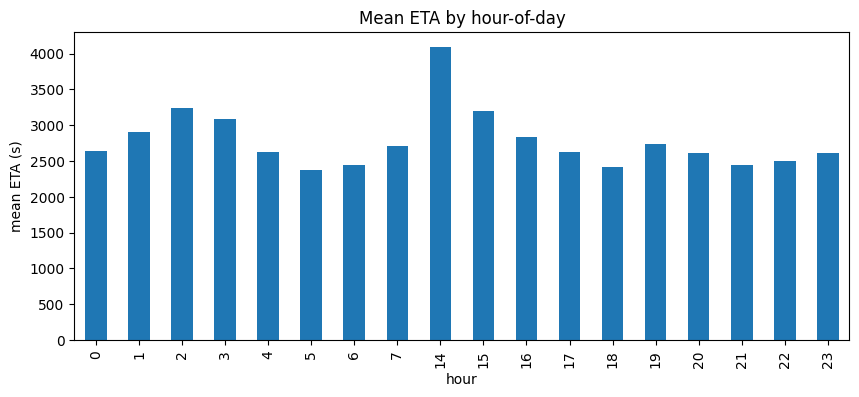

In [4]:
# ETA by hour-of-day
train.groupby('hour')['delivery_duration'].mean().plot(kind='bar', figsize=(10, 4))
plt.ylabel('mean ETA (s)'); plt.title('Mean ETA by hour-of-day'); plt.show()

In [5]:
# Weekend vs weekday
train.groupby('is_weekend')['delivery_duration'].agg(['mean', 'median', 'count'])

,mean,median,count
is_weekend,,,
0,2787.693718,2591.0,107796
1,2903.271137,2729.0,50030


## 2. Marketplace Features

In [6]:
def add_marketplace_features(df):
    df = df.copy()
    onshift = df['total_onshift_dashers'].replace(0, np.nan)
    df['busy_ratio']        = df['total_busy_dashers']        / onshift
    df['orders_per_dasher'] = df['total_outstanding_orders']  / onshift
    df['busy_ratio']        = df['busy_ratio'].fillna(df['busy_ratio'].median())
    df['orders_per_dasher'] = df['orders_per_dasher'].fillna(df['orders_per_dasher'].median())
    return df

train = add_marketplace_features(train)
test  = add_marketplace_features(test)

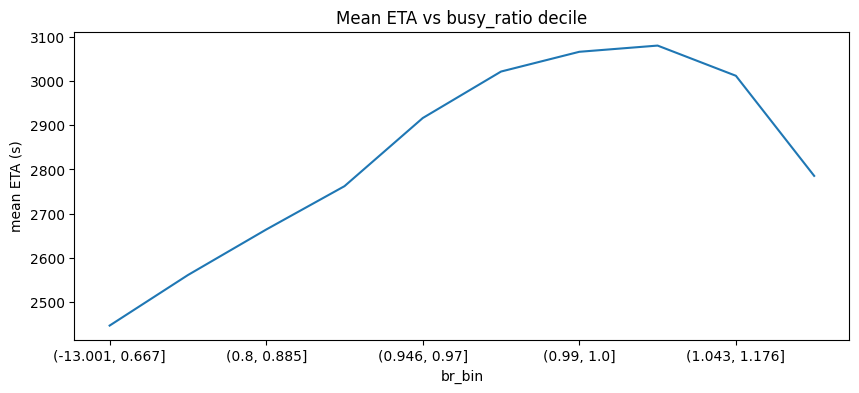

In [7]:
# Visualise relationship with ETA
tmp = train.assign(br_bin=pd.qcut(train['busy_ratio'], 10, duplicates='drop'))
tmp.groupby('br_bin', observed=True)['delivery_duration'].mean().plot(figsize=(10, 4))
plt.ylabel('mean ETA (s)'); plt.title('Mean ETA vs busy_ratio decile'); plt.show()

## 3. Price Features

In [8]:
def add_price_features(df):
    df = df.copy()
    items = df['total_items'].replace(0, np.nan)
    df['avg_item_price'] = df['subtotal'] / items
    df['price_range']    = df['max_item_price'] - df['min_item_price']
    df['avg_item_price'] = df['avg_item_price'].fillna(df['avg_item_price'].median())
    return df

train = add_price_features(train)
test  = add_price_features(test)

## 4. Order-Complexity Features

In [9]:
def add_complexity_features(df):
    df = df.copy()
    distinct = df['num_distinct_items'].replace(0, np.nan)
    df['items_per_distinct_item'] = (df['total_items'] / distinct).fillna(1.0)
    return df

train = add_complexity_features(train)
test  = add_complexity_features(test)

## 5. Categorical Encoding

In [10]:
CATEGORICAL_COLS = ['market_id', 'order_protocol', 'store_primary_category']

encoders = {}
for col in CATEGORICAL_COLS:
    encoders[col] = train[col].astype('object').fillna('missing').value_counts(normalize=True).to_dict()

def apply_freq(df, encoders):
    df = df.copy()
    for col, mapping in encoders.items():
        s = df[col].astype('object').fillna('missing')
        df[f'{col}_freq'] = s.map(mapping).fillna(0.0).astype(float)
    return df

train = apply_freq(train, encoders)
test  = apply_freq(test,  encoders)

## 6. Missingness as Signal & Log Transforms

In [11]:
# Missingness as signal — dasher columns and store_primary_category are NA together;
# capture that pattern as binary flags BEFORE imputation so the model sees it.
missing_flag_cols = ['total_onshift_dashers', 'total_busy_dashers',
                     'total_outstanding_orders', 'store_primary_category']
for col in missing_flag_cols:
    for d in (train, test):
        d[f'{col}_is_missing'] = d[col].isna().astype(int)

# Log transforms — subtotal and item-price columns are right-skewed.
# Clip to 0 before log1p: prices cannot be negative and log1p(x < -1) is undefined.
log_cols = ['subtotal', 'min_item_price', 'max_item_price']
for col in log_cols:
    for d in (train, test):
        d[f'{col}_log'] = np.log1p(d[col].clip(lower=0))

print('new flag cols:', [f'{c}_is_missing' for c in missing_flag_cols])
print('new log  cols:', [f'{c}_log' for c in log_cols])

new flag cols: ['total_onshift_dashers_is_missing', 'total_busy_dashers_is_missing', 'total_outstanding_orders_is_missing', 'store_primary_category_is_missing']
new log  cols: ['subtotal_log', 'min_item_price_log', 'max_item_price_log']


## 7. Rebuild Linear Regression with Engineered Features

In [12]:
BASELINE_FEATURES = [
    'total_items', 'subtotal', 'num_distinct_items',
    'min_item_price', 'max_item_price',
    'estimated_order_place_duration',
    'estimated_store_to_consumer_driving_duration',
]

ENGINEERED_FEATURES = BASELINE_FEATURES + [
    'total_onshift_dashers', 'total_busy_dashers', 'total_outstanding_orders',
    'hour', 'day_of_week', 'month', 'is_weekend',
    'busy_ratio', 'orders_per_dasher',
    'avg_item_price', 'price_range',
    'items_per_distinct_item',
    'market_id_freq', 'order_protocol_freq', 'store_primary_category_freq',
    # missingness flags
    'total_onshift_dashers_is_missing', 'total_busy_dashers_is_missing',
    'total_outstanding_orders_is_missing', 'store_primary_category_is_missing',
    # log transforms
    'subtotal_log', 'min_item_price_log', 'max_item_price_log',
]

# Median-impute numerics using train medians only (no leakage)
numeric_to_impute = BASELINE_FEATURES + [
    'total_onshift_dashers', 'total_busy_dashers', 'total_outstanding_orders'
]
medians = train[numeric_to_impute].median()
for d in (train, test):
    d[numeric_to_impute] = d[numeric_to_impute].fillna(medians)

y_train = train['delivery_duration'].values
y_test  = test['delivery_duration'].values
Xb_train = train[BASELINE_FEATURES]
Xb_test  = test[BASELINE_FEATURES]
Xe_train = train[ENGINEERED_FEATURES].copy()
Xe_test  = test[ENGINEERED_FEATURES].copy()

# Replace ±inf (e.g. from ratio/log edge cases) with NaN, then fill with train medians
fill_vals = Xe_train.replace([np.inf, -np.inf], np.nan).median()
Xe_train  = Xe_train.replace([np.inf, -np.inf], np.nan).fillna(fill_vals)
Xe_test   = Xe_test.replace([np.inf, -np.inf], np.nan).fillna(fill_vals)

print('baseline X:', Xb_train.shape, ' engineered X:', Xe_train.shape)
print('NaN/inf remaining in Xe_train:', Xe_train.isna().sum().sum(),
      '/', np.isinf(Xe_train.values).sum())

baseline X: (157826, 7)  engineered X: (157826, 29)
NaN/inf remaining in Xe_train: 0 / 0


In [13]:
def regression_metrics(y_true, y_pred):
    return {
        'MAE':  mean_absolute_error(y_true, y_pred),
        'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'R2':   r2_score(y_true, y_pred),
    }

lr_b = LinearRegression().fit(Xb_train, y_train)
lr_e = LinearRegression().fit(Xe_train, y_train)
comparison = pd.DataFrame({
    'Baseline':            regression_metrics(y_test, lr_b.predict(Xb_test)),
    'Feature Engineered':  regression_metrics(y_test, lr_e.predict(Xe_test)),
}).T.round(2)
comparison

,MAE,RMSE,R2
Baseline,779.83,1061.75,0.09
Feature Engineered,706.41,961.79,0.26


In [14]:
train.to_csv('../reports/train_eng.csv', index=False)
test.to_csv('../reports/test_eng.csv', index=False)
import json
with open('../reports/feature_lists.json', 'w') as fh:
    json.dump({'baseline': BASELINE_FEATURES, 'engineered': ENGINEERED_FEATURES}, fh)
print('saved.')

saved.
